# Rossmann Store Sales Project

## Import Essential Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 2: Data Gathering & Initial Inspection

### 1. Loading the Datasets

#### Why use `low_memory=False`?
By default (`low_memory=True`), pandas guesses column data types in chunks, which can trigger warnings if data types change further down in large files. Setting **`low_memory=False`** forces pandas to read the entire file at once to accurately determine data types across all rows.

In [16]:
# Load the datasets using standard course syntax

train_df = pd.read_csv("../data/raw/train.csv", low_memory=False)
test_df = pd.read_csv("../data/raw/test.csv", low_memory=False)
store_df = pd.read_csv("../data/raw/store.csv", low_memory=False)

In [6]:
# Check the dimensions (rows and columns) using .shape

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Store shape:", store_df.shape)

Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


In [7]:
# View the first few rows of the training set

train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [17]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### 2. Check Data Types & Missing Values

In [8]:
# Check info for train dataset

print("--- Train Info ---")
print(train_df.info())

--- Train Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
None


In [9]:
# Check info for store dataset

print("\n--- Store Info ---")
print(store_df.info())


--- Store Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB
None


### 2. Check for Missing Values (Nulls)

In [10]:
# Check missing values in train and store

print("Missing values in Train:\n", train_df.isnull().sum())
print("\nMissing values in Store:\n", store_df.isnull().sum())

Missing values in Train:
 Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Missing values in Store:
 Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


## Phase 3: Exploratory Data Analysis & Data Cleaning

### 1. Converting Dates and Merging Datasets

In [11]:
# 1. Convert the Date column from string to datetime objects

train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])

In [12]:
# 2. Merge store metadata into train and test sets using the 'Store' column

train_merged = pd.merge(train_df, store_df, on='Store', how='left')
test_merged = pd.merge(test_df, store_df, on='Store', how='left')

In [13]:
# 3. Verify the merge and new shape

print("Merged Train shape:", train_merged.shape)
print("Merged Test shape:", test_merged.shape)

Merged Train shape: (1017209, 18)
Merged Test shape: (41088, 17)


In [50]:
# Preview the new columns added from store.csv

train_merged.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,


### 2. Check for Missing Values in Merged Data

In [15]:
# Check total missing values for each column in the merged training set

missing_train = train_merged.isnull().sum()
print("Missing values per column in train_merged:\n")
print(missing_train[missing_train > 0])

Missing values per column in train_merged:

CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


### 3. Handling Missing Values

#### 3.1 Handling Competition Distance

In [20]:
# Fill missing CompetitionDistance with a large placeholder value (e.g., max distance + 10000)
max_distance = train_merged['CompetitionDistance'].max()
train_merged['CompetitionDistance'] = train_merged['CompetitionDistance'].fillna(max_distance + 10000)
test_merged['CompetitionDistance'] = test_merged['CompetitionDistance'].fillna(max_distance + 10000)

#### 3.2: Handling Competitor Opening Dates & Promo2 Start Dates

In [21]:
# For competition open month/year and promo2 columns, fill NaN with 0 
# (indicating no competitor history or no Promo2 participation)
fill_cols = [
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
    'Promo2SinceWeek', 'Promo2SinceYear'
]

for col in fill_cols:
    train_merged[col] = train_merged[col].fillna(0)
    test_merged[col] = test_merged[col].fillna(0)

#### 3.3: Handling Promotion Intervals

In [22]:
# For PromoInterval, fill missing with an empty string or 'None'
train_merged['PromoInterval'] = train_merged['PromoInterval'].fillna('')
test_merged['PromoInterval'] = test_merged['PromoInterval'].fillna('')

#### 3.4: Verifying the Cleanup

In [24]:
# Verify remaining missing values in both train and test
print("Remaining missing values in train_merged:", train_merged.isnull().sum().sum())
print("Remaining missing values in test_merged:", test_merged.isnull().sum().sum())

Remaining missing values in train_merged: 0
Remaining missing values in test_merged: 11


In [25]:
# Check which columns have missing values in test_merged and how many they have
missing_counts = test_merged.isnull().sum()
print(missing_counts[missing_counts > 0])

Open    11
dtype: int64


In [26]:
# Fill missing 'Open' values in test_merged with 1 (assuming open)
test_merged['Open'] = test_merged['Open'].fillna(1)

In [27]:
# Verify again
print("Remaining missing values in test_merged:", test_merged.isnull().sum().sum())

Remaining missing values in test_merged: 0


### 4. Data Type Casting and Filtering Training Data

In [29]:
# Ensure Date is in datetime format for both train and test
train_merged['Date'] = pd.to_datetime(train_merged['Date'])
test_merged['Date'] = pd.to_datetime(test_merged['Date'])

print("Date column successfully cast to datetime.")

Date column successfully cast to datetime.


In [30]:
# Filter train_merged: Keep only rows where store is Open (Open == 1) and Sales > 0
# Rossmann competition guidelines typically focus training on days the store was open and generating revenue.
print(f"Original train shape: {train_merged.shape}")

train_filtered = train_merged[(train_merged['Open'] == 1) & (train_merged['Sales'] > 0)].copy()

print(f"Filtered train shape: {train_filtered.shape}")

Original train shape: (1017209, 18)
Filtered train shape: (844338, 18)


## Phase 4: Exploratory Data Analysis (EDA) & Statistics

### 1.Day of the Week Sales Analysis

Average Sales by Day of the Week:
   DayOfWeek        Sales
0          1  8216.252259
1          2  7088.409086
2          3  6728.786679
3          4  6768.214973
4          5  7073.034133
5          6  5875.084935
6          7  8224.723908


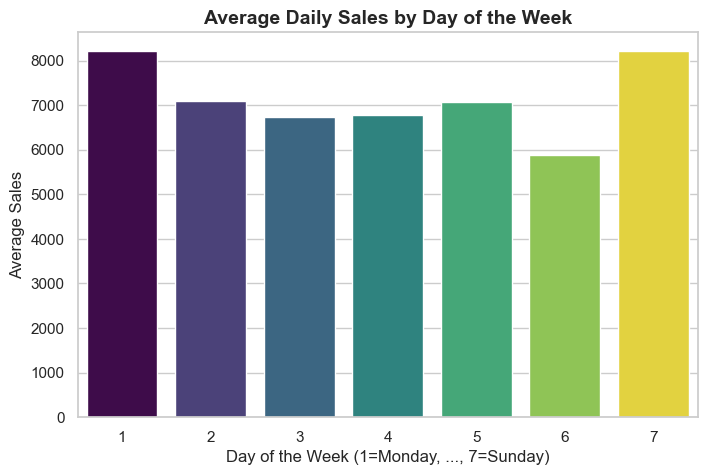

In [34]:

# Set style for cleaner plots
sns.set_theme(style="whitegrid")

# Group by DayOfWeek and calculate average sales
dow_sales = train_filtered.groupby('DayOfWeek')['Sales'].mean().reset_index()

print("Average Sales by Day of the Week:")
print(dow_sales)

# Plot average sales by day of the week
plt.figure(figsize=(8, 5))
sns.barplot(x='DayOfWeek', y='Sales', data=dow_sales, palette='viridis', hue='DayOfWeek', legend=False)
plt.title('Average Daily Sales by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week (1=Monday, ..., 7=Sunday)', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()

* **Finding:** Average sales peak sharply on **Monday (1)** and **Sunday (7)**, with a noticeable dip over the middle and end of the week (Saturday).
* **Takeaway:** The unusually high average on Sundays happens because only a small, select group of specialized stores (such as those in train stations or airports) choose to operate on Sundays, capturing heavy customer traffic. Mondays see a similar spike as normal stores experience a major rush right after being closed on Sunday.

### Checking Sunday Open Stores

In [39]:
# Filter the dataset for Day 7 (Sundays)
sunday_sales = train_filtered[train_filtered['DayOfWeek'] == 7]

# See how many total records and unique stores are open on Sunday
print(f"Total Sunday open records: {len(sunday_sales)}")
print(f"Unique stores open on Sunday: {sunday_sales['Store'].nunique()}")

# Look at a sample of these rows to see which stores are open
display(sunday_sales[['Store', 'Date', 'Sales', 'Open']].head())

Total Sunday open records: 3593
Unique stores open on Sunday: 33


,Store,Date,Sales,Open
5659,85,2015-07-26,11421,1
5696,122,2015-07-26,5773,1
5783,209,2015-07-26,3742,1
5833,259,2015-07-26,15998,1
5836,262,2015-07-26,32547,1


### 2.Impact of Promotions on Sales

   Promo        Sales
0      0  5929.826183
1      1  8228.739731


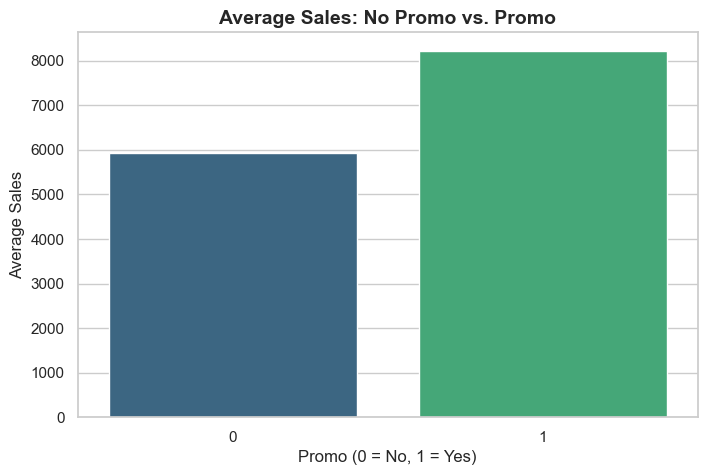

In [44]:
# group by promo status and get average sales
promo_sales = train_filtered.groupby('Promo')['Sales'].mean().reset_index()
print(promo_sales)

plt.figure(figsize=(8, 5))
sns.barplot(x='Promo', y='Sales', data=promo_sales, palette='viridis', hue='Promo', legend=False)
plt.title('Average Sales: No Promo vs. Promo', fontsize=14, fontweight='bold')
plt.xlabel('Promo (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()

* **Finding:** Average sales are substantially higher when a promotion is active (`1`) compared to when there is no promotion (`0`).
* **Takeaway:** Marketing campaigns and discounts successfully drive customer purchasing behavior and boost overall store revenue.

### 3.Average Sales by Store Type

  StoreType         Sales
0         a   6925.697986
1         b  10233.380141
2         c   6933.126425
3         d   6822.300064


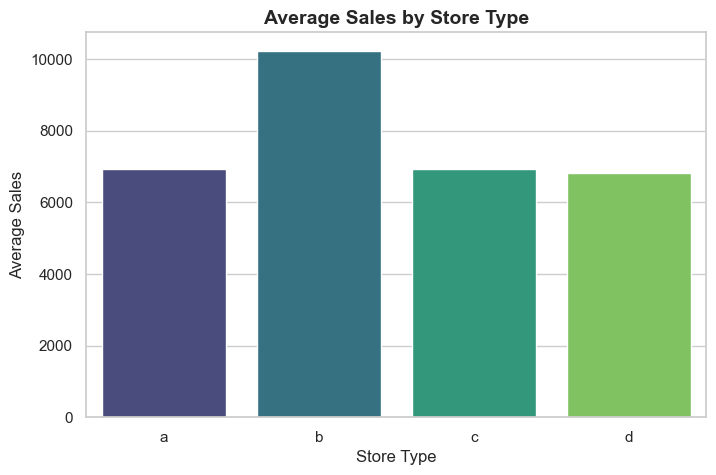

In [46]:
# group by store type and get average sales
storetype_sales = train_filtered.groupby('StoreType')['Sales'].mean().reset_index()
print(storetype_sales)

plt.figure(figsize=(8, 5))
sns.barplot(x='StoreType', y='Sales', data=storetype_sales, palette='viridis', hue='StoreType', legend=False)
plt.title('Average Sales by Store Type', fontsize=14, fontweight='bold')
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()

* **Finding:** Store type **b** has significantly higher average sales compared to all other store types (a, c, and d).
* **Takeaway:** Store type **b** represents high-performing formats (often larger flagships or specialized locations) that generate much more revenue per day.

### 4.Average Sales by Assortment Type

  Assortment        Sales
0          a  6621.523057
1          b  8642.503594
2          c  7300.843547


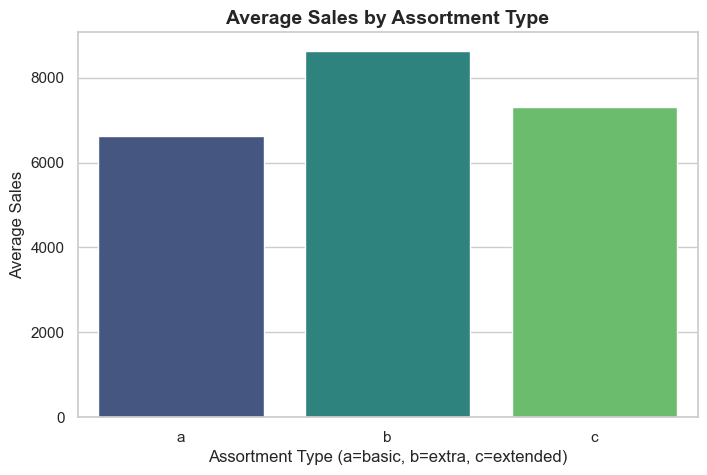

In [47]:
# group by assortment and get average sales
assortment_sales = train_filtered.groupby('Assortment')['Sales'].mean().reset_index()
print(assortment_sales)

plt.figure(figsize=(8, 5))
sns.barplot(x='Assortment', y='Sales', data=assortment_sales, palette='viridis', hue='Assortment', legend=False)
plt.title('Average Sales by Assortment Type', fontsize=14, fontweight='bold')
plt.xlabel('Assortment Type (a=basic, b=extra, c=extended)', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()

* **Finding:** Assortment type **b** achieves the highest average sales, outperforming both basic (a) and extended (c) assortments.
* **Takeaway:** Offering extra product variety plays a major role in driving higher customer spending.

### 5.Average Sales by State Holiday

  StateHoliday        Sales
0            0  6953.960229
1            a  8487.471182
2            b  9887.889655
3            c  9743.746479


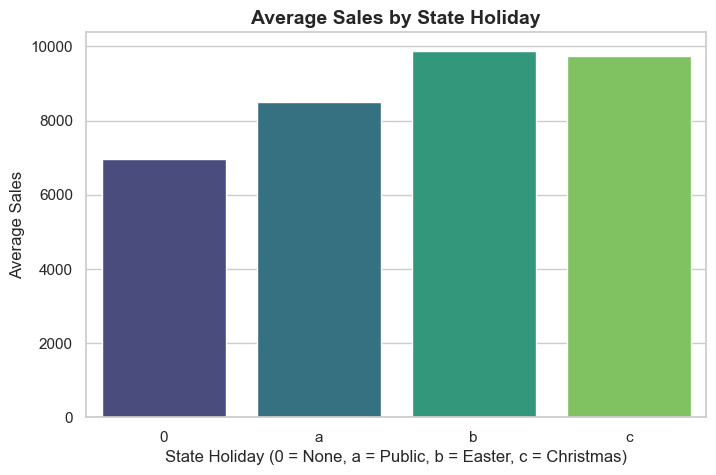

In [48]:
# group by state holiday and get average sales
holiday_sales = train_filtered.groupby('StateHoliday')['Sales'].mean().reset_index()
print(holiday_sales)

plt.figure(figsize=(8, 5))
sns.barplot(x='StateHoliday', y='Sales', data=holiday_sales, palette='viridis', hue='StateHoliday', legend=False)
plt.title('Average Sales by State Holiday', fontsize=14, fontweight='bold')
plt.xlabel('State Holiday (0 = None, a = Public, b = Easter, c = Christmas)', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()

* **Finding:** Average sales spike notably when stores open on state or public holidays (`a`, `b`, and `c`), while normal days (`0`) average lower revenue.
* **Takeaway:** Only select stores (like those in travel hubs or tourist zones) open on holidays, and customers spend heavily on those specific days off.

### 6.Average Sales by School Holiday

   SchoolHoliday        Sales
0              0  6897.207830
1              1  7200.710282


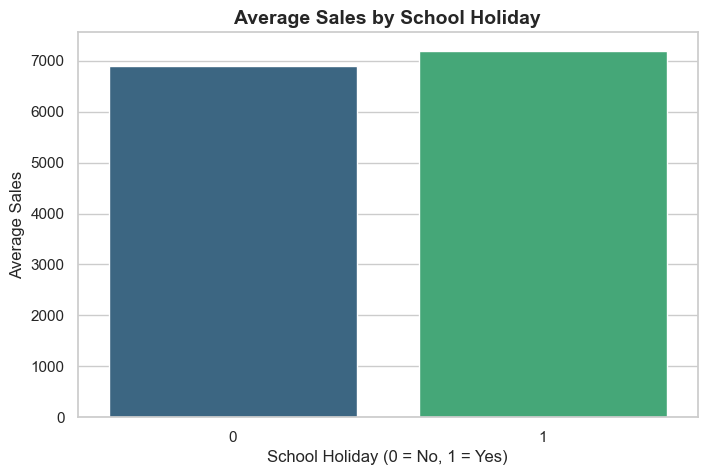

In [51]:
# group by school holiday and get average sales
school_sales = train_filtered.groupby('SchoolHoliday')['Sales'].mean().reset_index()
print(school_sales)

plt.figure(figsize=(8, 5))
sns.barplot(x='SchoolHoliday', y='Sales', data=school_sales, palette='viridis', hue='SchoolHoliday', legend=False)
plt.title('Average Sales by School Holiday', fontsize=14, fontweight='bold')
plt.xlabel('School Holiday (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()

* **Finding:** Sales are slightly higher during school holidays (`1`) compared to normal school periods (`0`).
* **Takeaway:** Families having free time during school breaks contributes to a minor boost in overall shopping activity.

### 7.Average Sales by Month

    Month        Sales
0       1  6564.298651
1       2  6589.494012
2       3  6976.817749
3       4  7046.659509
4       5  7106.808038
5       6  7001.402127
6       7  6953.575827
7       8  6649.229053
8       9  6547.469104
9      10  6602.967255
10     11  7188.554250
11     12  8608.956661


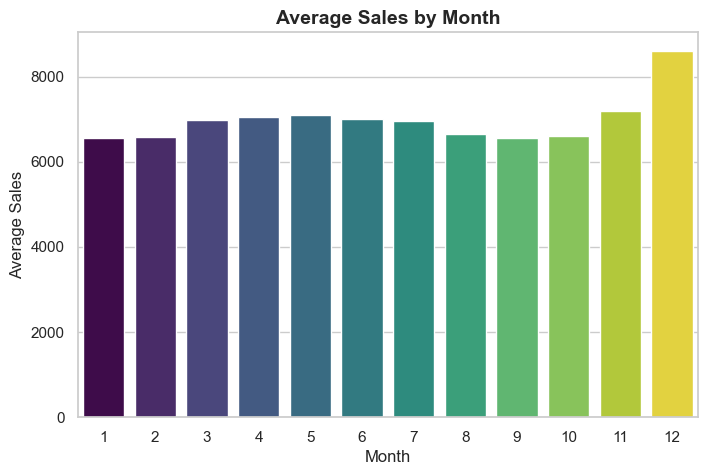

In [54]:
# Extract the month number from the date column
train_filtered['Month'] = pd.to_datetime(train_filtered['Date']).dt.month

# Group by month and calculate average sales
month_sales = train_filtered.groupby('Month')['Sales'].mean().reset_index()
print(month_sales)

# Plot average sales by month
plt.figure(figsize=(8, 5))
sns.barplot(x='Month', y='Sales', data=month_sales, palette='viridis', hue='Month', legend=False)
plt.title('Average Sales by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()

* **Finding:** Sales remain fairly steady throughout most of the year, but experience a massive surge in **December (Month 12)**.
* **Takeaway:** Holiday shopping and Christmas preparations heavily drive up retail sales at the end of the year.

### 8.Average Sales by Year

   Year        Sales
0  2013  6814.775168
1  2014  7026.128505
2  2015  7088.235123


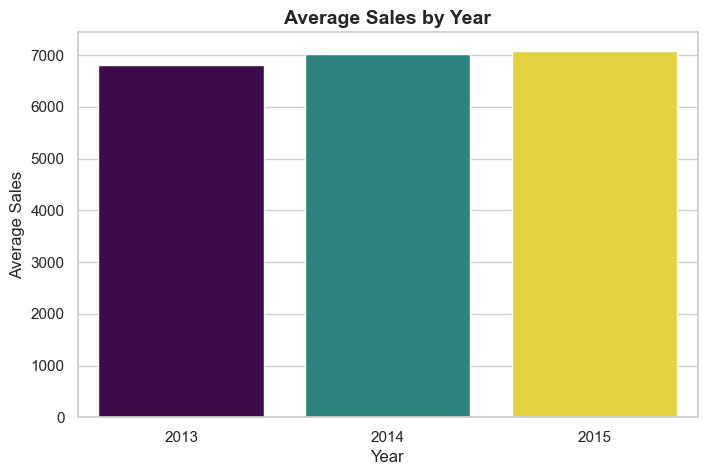

In [55]:
# Extract the year from the date column
train_filtered['Year'] = pd.to_datetime(train_filtered['Date']).dt.year

# Group by year and calculate average sales
year_sales = train_filtered.groupby('Year')['Sales'].mean().reset_index()
print(year_sales)

# Plot average sales by year
plt.figure(figsize=(8, 5))
sns.barplot(x='Year', y='Sales', data=year_sales, palette='viridis', hue='Year', legend=False)
plt.title('Average Sales by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()

* **Finding:** Average daily sales show a steady, consistent upward trend from 2013 through 2015.
* **Takeaway:** The business experienced healthy multi-year growth and stable customer demand over time.

### 9.Correlation Heatmap of Numerical Features

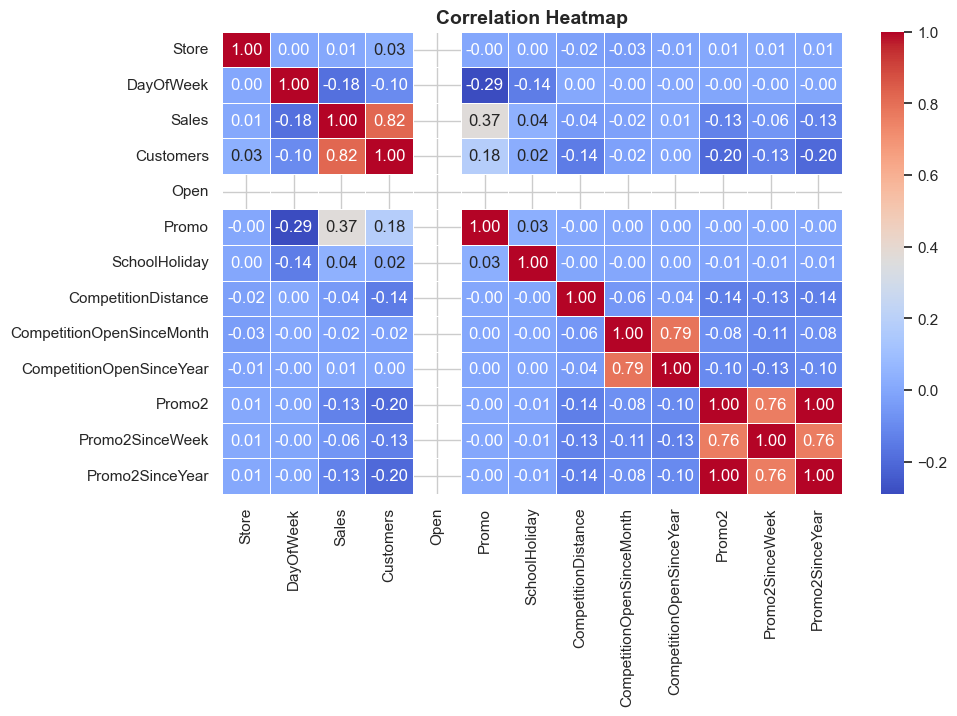

In [56]:
# Select only numerical columns for correlation
num_cols = train_filtered.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
corr_matrix = num_cols.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

### Key Insights from the Correlation Matrix:
* **Customers & Sales (0.82):** Strong positive correlation, meaning more foot traffic directly leads to higher sales.
* **Promo & Sales (0.37):** Moderate positive correlation, supporting our earlier finding that active promotions help drive revenue.

### Checking for Missing Values

In [59]:
# Check for any missing values in the filtered dataset
missing_values = train_filtered.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


### Save the Cleaned Data

In [62]:
# Save the cleaned dataframe to data directory
train_filtered.to_csv('../data/processed/train_cleaned.csv', index=False)
